In [ ]:
# Vanishing gradient occurs when gradients become extremely small during backpropagation, 
# It preventing the neural network from learning effectively, especially in deep networks.
# Loss does not reduce as weight not update

In [1]:
# Code Example
import tensorflow
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.layers import Dense
from keras import Sequential
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

In [4]:
# Create Datasets
X,y = make_moons(n_samples=250, noise=0.05, random_state=42)

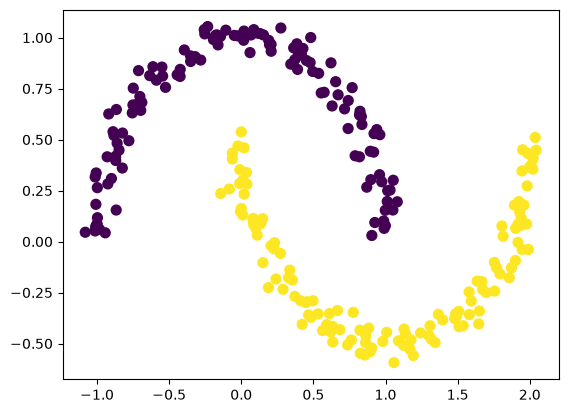

In [5]:
# Create plot to know the data
plt.scatter(X[:,0], X[:,1], c=y, s=50)
plt.show()

In [6]:
# Create Neural Network 
model=Sequential()
model.add(Dense(10, activation='sigmoid', input_dim=2))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\Kamely\Desktop\Deep_Learning\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [8]:
# Extract the weights of first layer
model.get_weights()[0]

array([[-0.58636564, -0.07763988, -0.48906004,  0.27802706,  0.01791209,
         0.69394773,  0.65415496, -0.14463228,  0.44530588,  0.6894687 ],
       [ 0.5946074 ,  0.28254658, -0.00821459,  0.31839055,  0.5316171 ,
         0.6138533 , -0.4714489 , -0.42844817, -0.5321847 , -0.39928424]],
      dtype=float32)

In [9]:
# Store as a old weights
old_weights = model.get_weights()[0]

In [10]:
# Split the data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [11]:
# Train the model
model.fit(X_train, y_train, epochs = 1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4900 - loss: 0.6962


In [12]:
# Store new weights
new_weights = model.get_weights()[0]

In [15]:
# Get learning rate
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [16]:
# Calculate gradient
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [17]:
gradient

array([[-0.00190735,  0.30625612,  0.1334548 ,  0.02393126,  0.10282732,
        -0.00965595,  0.18662213,  0.17297266,  0.10380148, -0.09721517],
       [ 0.00786781, -0.28175116, -0.13716333, -0.02041459, -0.08827447,
         0.01132488, -0.21809338, -0.15828012, -0.1065731 ,  0.11259317]],
      dtype=float32)

In [18]:
percent_change

array([[3.2528315e-04, 3.9445722e-01, 2.7288020e-02, 8.6075310e-03,
        5.7406658e-01, 1.3914524e-03, 2.8528737e-02, 1.1959480e-01,
        2.3310155e-02, 1.4100013e-02],
       [1.3231946e-03, 9.9718481e-02, 1.6697520e+00, 6.4118081e-03,
        1.6604898e-02, 1.8448842e-03, 4.6260241e-02, 3.6942657e-02,
        2.0025585e-02, 2.8198753e-02]], dtype=float32)

In [19]:
old_weights

array([[-0.58636564, -0.07763988, -0.48906004,  0.27802706,  0.01791209,
         0.69394773,  0.65415496, -0.14463228,  0.44530588,  0.6894687 ],
       [ 0.5946074 ,  0.28254658, -0.00821459,  0.31839055,  0.5316171 ,
         0.6138533 , -0.4714489 , -0.42844817, -0.5321847 , -0.39928424]],
      dtype=float32)

In [20]:
new_weights

array([[-0.58636373, -0.07794613, -0.4891935 ,  0.27800313,  0.01780926,
         0.6939574 ,  0.65396833, -0.14480525,  0.44520208,  0.6895659 ],
       [ 0.59459955,  0.28282833, -0.00807743,  0.31841096,  0.5317054 ,
         0.61384195, -0.4712308 , -0.4282899 , -0.53207815, -0.39939684]],
      dtype=float32)

# Here, No update happen

In [ ]:
# Increases the number of epochs
# Try to show whether loss function change or not
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4900 - loss: 0.6944 
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4900 - loss: 0.6933 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5100 - loss: 0.6933 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - loss: 0.6932 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6930 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5100 - lo

# Here, Loss does not change

        #------ How to reduce Vanishing gradient------#
# 1.Reduce model complexity
# 2.Use Relu function instead of sigmoid
# 3.Initialization of prpper weights
# 4.Batch normalization
# 5.Residual Network

In [22]:
# Create shallow Neural Network
model = Sequential()
model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\Kamely\Desktop\Deep_Learning\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
# Compile the model
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [24]:
# Extract old weights
old_weights = model.get_weights()[0]

In [25]:
# Train the model
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4900 - loss: 0.6960
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6945 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6938 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.6931 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5200 - loss: 0.6933 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6000 - loss: 0.6921 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6919 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6916 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6913 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6909 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5100 - loss: 0.6907
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5100 - loss

# Here, loss reduce through epochs

In [26]:
new_weights = model.get_weights()[0]

In [27]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [28]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [29]:
gradient

array([[  681.9889 ,   505.98203,  -709.0124 ,   528.1445 ,  -481.70975,
          529.745  ,  -685.202  ,   732.34607,   584.43616,  -484.44025],
       [ -895.5128 ,  -967.2128 ,  1176.941  , -1004.2381 ,  1115.3757 ,
         -726.8946 ,   914.3297 , -1090.6365 , -1138.5433 ,  1036.503  ]],
      dtype=float32)

In [30]:
percent_change

array([[  97.226524,  494.03134 ,  963.3143  ,  161.14958 ,   74.54462 ,
         498.95392 ,  130.46155 ,  242.08925 ,  109.9381  ,   90.31    ],
       [ 130.15717 ,  149.02176 , 4540.255   ,  147.4116  , 2277.5337  ,
         203.62685 ,  570.9819  ,  670.25464 , 1921.0938  ,  413.01324 ]],
      dtype=float32)

In [31]:
old_weights

array([[ 0.70144325, -0.10241902,  0.07360137, -0.32773557,  0.64620334,
         0.10617113, -0.5252138 ,  0.3025108 , -0.53160477,  0.53641933],
       [ 0.6880242 ,  0.64904135,  0.02592236,  0.68124765, -0.04897296,
        -0.35697386, -0.16013288,  0.16271973, -0.05926538, -0.2509612 ]],
      dtype=float32)

In [32]:
new_weights

array([[ 0.01945438, -0.60840106,  0.7826138 , -0.8558801 ,  1.1279131 ,
        -0.4235739 ,  0.15998828, -0.42983532, -1.116041  ,  1.0208596 ],
       [ 1.5835371 ,  1.6162542 , -1.1510187 ,  1.6854858 , -1.1643487 ,
         0.36992076, -1.0744627 ,  1.2533562 ,  1.079278  , -1.2874643 ]],
      dtype=float32)

In [33]:
# Create Neural Network by using relu
model=Sequential()
model.add(Dense(10, activation='relu', input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [34]:
# Compile the model
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [35]:
# Extract old weights
old_weights = model.get_weights()[0]

In [36]:
# Train the model
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4900 - loss: 0.6944
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6910 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6885 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5100 - loss: 0.6855 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6812 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7400 - loss: 0.6741 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7800 - loss: 0.6632 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8200 - loss: 0.6467 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8200 - loss: 0.6218 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8150 - loss: 0.5910 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8100 - loss: 0.5473 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8150 - loss

In [37]:
new_weights=model.get_weights()[0]

In [ ]:
model.optimizer.get_config()['learning_rate']

0.0010000000474974513

In [40]:
gradient=(old_weights-new_weights)/0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [41]:
gradient

array([[-110.041336 , -140.60413  ,  160.87215  ,    6.199166 ,
         172.49727  ,   49.162968 ,  -34.797997 ,  -65.23191  ,
           2.7291474,  114.6245   ],
       [ -66.472885 ,  -41.365204 , -127.460655 ,   -8.371651 ,
        -151.27771  ,  -34.251213 ,    5.7634706,   53.9831   ,
          47.481506 , -112.31395  ]], dtype=float32)

In [42]:
old_weights

array([[-0.163504  ,  0.5274357 , -0.39861882,  0.09556729, -0.3987139 ,
         0.01995403,  0.2670315 , -0.16128671,  0.33920234, -0.03897387],
       [ 0.24948472, -0.36674854, -0.24310184, -0.22069642, -0.03901851,
         0.21802902, -0.5388975 ,  0.05498362, -0.37192133, -0.4970044 ]],
      dtype=float32)

In [43]:
new_weights

array([[-0.05346266,  0.66803986, -0.559491  ,  0.08936812, -0.57121116,
        -0.02920894,  0.3018295 , -0.0960548 ,  0.3364732 , -0.15359837],
       [ 0.3159576 , -0.32538334, -0.11564117, -0.21232477,  0.1122592 ,
         0.25228024, -0.544661  ,  0.00100051, -0.41940284, -0.38469043]],
      dtype=float32)